In [5]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
from sklearn.model_selection import train_test_split

In [6]:
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

In [7]:
def extract_keypoints(image_path):
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = pose.process(image_rgb)
    if results.pose_landmarks:
        keypoints = []
        for lm in results.pose_landmarks.landmark:
            keypoints.extend([lm.x, lm.y, lm.visibility])
        return keypoints
    else:
        return None

In [8]:
dataset_path = "training_data"
data = []
labels = []

In [9]:
for pose_name in os.listdir(dataset_path):
    pose_folder = os.path.join(dataset_path, pose_name)
    if os.path.isdir(pose_folder):
        for image_file in os.listdir(pose_folder):
            image_path = os.path.join(pose_folder, image_file)
            keypoints = extract_keypoints(image_path)
            if keypoints:  # If pose landmarks are detected
                data.append(keypoints)
                labels.append(pose_name)

c:\Users\USER\anaconda3\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


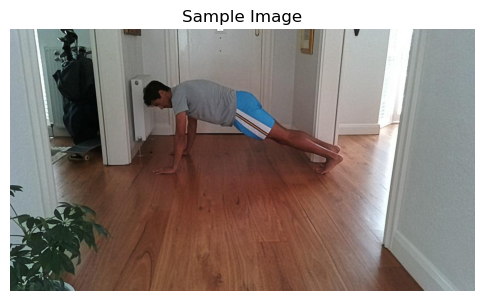

In [10]:
image_path = 'D:/Posture_detection/training_data/Pushups/1_10798_jpg.rf.1c1734ed9d5a3f0839517b7210012c3c.jpg'
sample_img = cv2.imread(image_path) 
# Check if the image is loaded successfully 
if sample_img is None: 
    print("Error: Image not loaded. Check the file path.") 
else: 
    plt.figure(figsize=(6, 6)) 
    plt.title('Sample Image') 
    plt.axis('off') 
    plt.imshow(sample_img[:, :, ::-1]) 
    plt.show()

In [11]:
results = pose.process(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))

if results.pose_landmarks:
  for i in range(0,32):
    print(f'{mp_pose.PoseLandmark(i).name}:\n{results.pose_landmarks.landmark[mp_pose.PoseLandmark(i).value]}')

NOSE:
x: 0.328060508
y: 0.303892165
z: 0.00272553531
visibility: 0.999833822

LEFT_EYE_INNER:
x: 0.319181591
y: 0.29390946
z: -0.0187827442
visibility: 0.99983418

LEFT_EYE:
x: 0.318973631
y: 0.291963965
z: -0.0188079644
visibility: 0.999809921

LEFT_EYE_OUTER:
x: 0.318743527
y: 0.289912969
z: -0.0188070275
visibility: 0.99987042

RIGHT_EYE_INNER:
x: 0.319697112
y: 0.293192297
z: 0.0102078607
visibility: 0.999834895

RIGHT_EYE:
x: 0.319804847
y: 0.290671051
z: 0.010231385
visibility: 0.999807298

RIGHT_EYE_OUTER:
x: 0.319857866
y: 0.287861139
z: 0.0102310469
visibility: 0.999889731

LEFT_EAR:
x: 0.323430955
y: 0.269654065
z: -0.071738407
visibility: 0.999744952

RIGHT_EAR:
x: 0.324530929
y: 0.266894251
z: 0.0568421707
visibility: 0.999813139

MOUTH_LEFT:
x: 0.336765468
y: 0.30035454
z: -0.0126770176
visibility: 0.999742448

MOUTH_RIGHT:
x: 0.337640435
y: 0.299932539
z: 0.0250797756
visibility: 0.99964571

LEFT_SHOULDER:
x: 0.361298501
y: 0.284852147
z: -0.142807528
visibility: 0.999877

In [12]:
num_classes = len(os.listdir(dataset_path))
print(f'Number of classes: {num_classes}')

Number of classes: 2


In [13]:
import tensorflow as tf
data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    label_mode="categorical",
    seed=123,
    image_size=(256, 256),
    batch_size=32
)

Found 893 files belonging to 2 classes.


In [14]:
# Normalize data
data = data.map(lambda x, y: (x / 255.0, y))

# Determine dataset size
dataset_size = len(data)

In [15]:
train_data = "D:/Posture_detection/training_data"
val_data = "D:/Posture_detection/Validation data"

In [21]:
train_size = int(0.7 * dataset_size)
train_data = data.take(train_size)

val_size = int(0.2*dataset_size)
val_data = data.take(val_size)

In [17]:
dataset_size
train_data = "D:/Posture_detection/training_data"
val_data = "D:/Posture_detection/Validation data"

### Preprocessing Methods

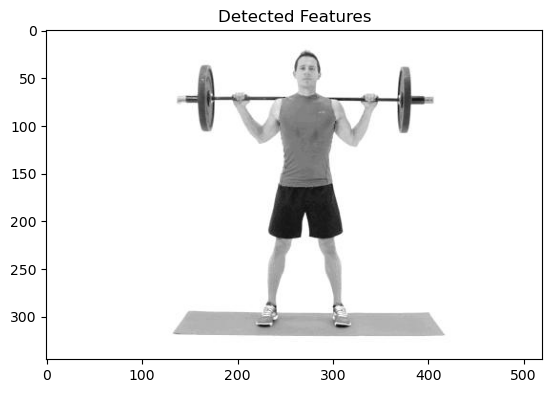

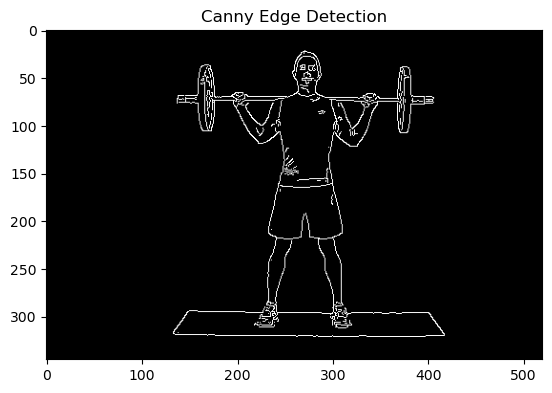

In [18]:
img = cv2.imread("D:/Posture_detection/training_data/Squat/0_jpg.rf.2e547209e27413612d6aef1d00285e40.jpg")

# Convert the image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect edges using Canny
edges = cv2.Canny(gray, 70, 130)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Detected Features')
plt.show()

# Display the edge-detected image
plt.imshow(edges, cmap='gray')
plt.title('Canny Edge Detection')
plt.show()


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

# Build the model
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    MaxPooling2D(),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(),
    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')  # Output layer for num_classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
# hist = model.fit(train_data, validation_data=val_data, epochs= 15, callbacks=[early_stopping])

In [23]:
hist = model.fit(train_data, validation_data=val_data, epochs= 15, callbacks=[early_stopping])

Epoch 1/15
19/19 [==============================] - 13s 589ms/step - loss: 0.4435 - accuracy: 0.8158 - val_loss: 0.2109 - val_accuracy: 0.8938
Epoch 2/15
19/19 [==============================] - 11s 559ms/step - loss: 0.1204 - accuracy: 0.9655 - val_loss: 0.0391 - val_accuracy: 0.9812
Epoch 3/15
19/19 [==============================] - 14s 696ms/step - loss: 0.1123 - accuracy: 0.9638 - val_loss: 0.0496 - val_accuracy: 0.9937
Epoch 4/15
19/19 [==============================] - 13s 658ms/step - loss: 0.0259 - accuracy: 0.9918 - val_loss: 0.0112 - val_accuracy: 1.0000
Epoch 5/15
19/19 [==============================] - 14s 681ms/step - loss: 0.0095 - accuracy: 0.9967 - val_loss: 0.0118 - val_accuracy: 1.0000
Epoch 6/15
19/19 [==============================] - 14s 693ms/step - loss: 0.0134 - accuracy: 0.9951 - val_loss: 0.0023 - val_accuracy: 1.0000
Epoch 7/15
19/19 [==============================] - 14s 705ms/step - loss: 0.0037 - accuracy: 0.9984 - val_loss: 0.0025 - val_accuracy: 1.0000

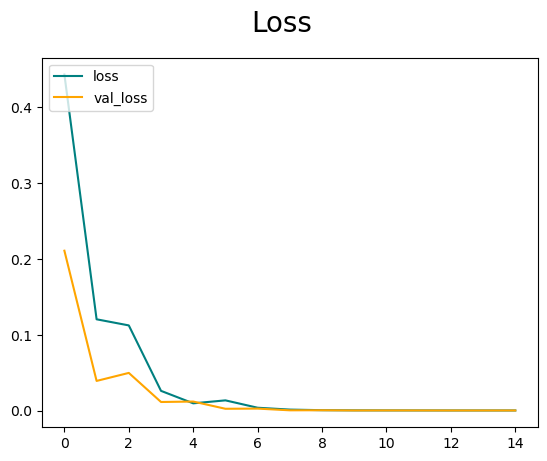

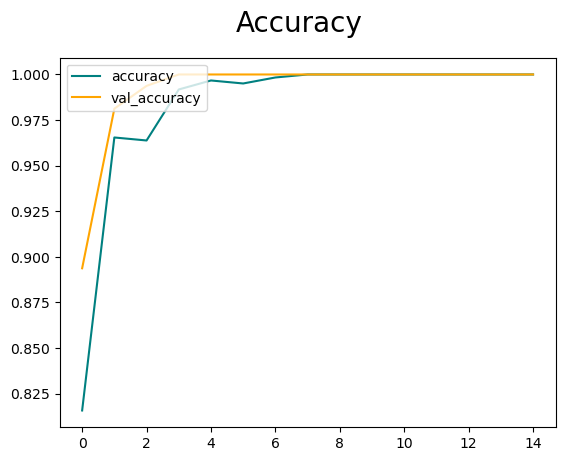

In [24]:
# Plot loss
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

# Plot accuracy
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

#Test 

2/2 [==============================] - 2s 275ms/step - loss: 1.4740e-04 - accuracy: 1.0000
Test loss: 0.00014739572361577302
Test accuracy: 1.0
1/1 [==============================] - 0s 168ms/step
Precision: 1.0, Recall: 1.0, Accuracy: 1.0
1/1 [==============================] - 0s 104ms/step
[[1. 0.]]
The predicted emotion is: Pushups


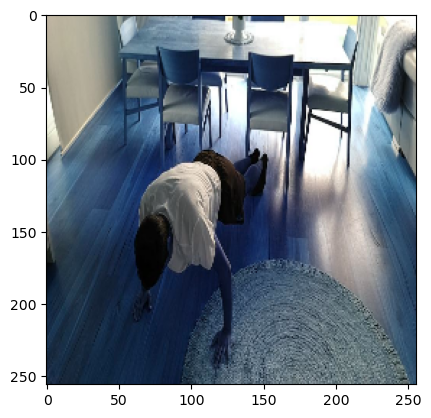

In [25]:
test_data = "D:/Posture_detection/Testing data"
test_size = int(0.1 * dataset_size)
test_data = data.skip(train_size + val_size).take(test_size)


results = model.evaluate(test_data)
print("Test loss:", results[0])
print("Test accuracy:", results[1])

# Calculate precision, recall, and accuracy
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

for images, labels in test_data:
    predictions = model.predict(images)
    pre.update_state(labels, predictions)
    re.update_state(labels, predictions)
    acc.update_state(labels, predictions)

print(f'Precision: {pre.result().numpy()}, Recall: {re.result().numpy()}, Accuracy: {acc.result().numpy()}')

# Test the model with a new image
img = cv2.imread('D:/Posture_detection/Testing data/Pushups/5_98522_jpg.rf.0fa9043cf1f10df64c3e83b17be0fa02.jpg')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
# plt.show()

resize = tf.image.resize(img, (256, 256))
plt.imshow(resize.numpy().astype(int))
# plt.show()

predictions = model.predict(np.expand_dims(resize, axis=0))

# Get the class label
class_labels = ['Pushups', 'Squats', 'Extras']
print(predictions)
predicted_class_index = np.argmax(predictions)

#prediction of images
if predicted_class_index < len(class_labels):
    predicted_class = class_labels[predicted_class_index]
    print(f'The predicted emotion is: {predicted_class}')
else: 
    print("Error: Predicted class index exceeds class labels list.")

In [26]:
model.save("Pose.h5")

c:\Users\USER\anaconda3\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [1]:
import cv2
import numpy as np
import tensorflow as tf
import mediapipe as mp

# Load your trained model
model = tf.keras.models.load_model("Pose.h5")  # Replace with your model path
class_names = ["pushup", "squat", "extra"]  # Replace with your class names

# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5)
mp_drawing = mp.solutions.drawing_utils

# Function to preprocess the pose image
def preprocess_image(image, target_size=(224, 224)):
    image = cv2.resize(image, target_size)  # Resize to model's input size
    image = image / 255.0  # Normalize pixel values to [0, 1]
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    return image

# Start webcam feed
cap = cv2.VideoCapture(0)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame.")
        break

    # Flip the frame horizontally for a mirror effect
    frame = cv2.flip(frame, 1)
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for MediaPipe

    # Detect pose using MediaPipe
    results = pose.process(frame_rgb)

    # If pose landmarks are detected
    if results.pose_landmarks:
        # Draw the pose landmarks on the frame
        mp_drawing.draw_landmarks(
            frame, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(245, 117, 66), thickness=2, circle_radius=2),
            mp_drawing.DrawingSpec(color=(66, 245, 117), thickness=2, circle_radius=2),
        )

        # Get bounding box around the detected pose
        h, w, c = frame.shape  # Frame dimensions
        pose_landmarks = results.pose_landmarks.landmark

        # Find the min and max coordinates of the landmarks
        x_min = int(min([landmark.x for landmark in pose_landmarks]) * w)
        x_max = int(max([landmark.x for landmark in pose_landmarks]) * w)
        y_min = int(min([landmark.y for landmark in pose_landmarks]) * h)
        y_max = int(max([landmark.y for landmark in pose_landmarks]) * h)

        # Ensure the bounding box stays within the frame dimensions
        x_min = max(0, x_min)
        y_min = max(0, y_min)
        x_max = min(w, x_max)
        y_max = min(h, y_max)

        # Extract the region of interest (ROI)
        pose_roi = frame[y_min:y_max, x_min:x_max]

        # Preprocess the ROI and make predictions
        if pose_roi.size > 0:
            input_image = preprocess_image(pose_roi)
            prediction = model.predict(input_image)
            predicted_class = class_names[np.argmax(prediction)]

            # Display prediction result
            cv2.putText(
                frame, f"Class: {predicted_class}", (x_min, y_min - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2, cv2.LINE_AA
            )

    # Display the frame
    cv2.imshow("Pose Detection and Classification", frame)

    # Press 'q' to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()
pose.close()


c:\Users\USER\anaconda3\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


ValueError: in user code:

    File "c:\Users\USER\anaconda3\Lib\site-packages\keras\src\engine\training.py", line 2341, in predict_function  *
        return step_function(self, iterator)
    File "c:\Users\USER\anaconda3\Lib\site-packages\keras\src\engine\training.py", line 2327, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "c:\Users\USER\anaconda3\Lib\site-packages\keras\src\engine\training.py", line 2315, in run_step  **
        outputs = model.predict_step(data)
    File "c:\Users\USER\anaconda3\Lib\site-packages\keras\src\engine\training.py", line 2283, in predict_step
        return self(x, training=False)
    File "c:\Users\USER\anaconda3\Lib\site-packages\keras\src\utils\traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "c:\Users\USER\anaconda3\Lib\site-packages\keras\src\engine\input_spec.py", line 298, in assert_input_compatibility
        raise ValueError(

 